# 03 — The AI Model: Finding Real Dips and Rejecting False Ones

**Hack4Dev Iraq 2026 · Exoplanet Data Challenge · Track F (AI Challenge)**
Team: Mostafa & Sara

Notebook 02 gave us light curves: for every star, on every night, its brightness over time.
Now we build the actual AI part of the project.

## The problem in one sentence

A dip in a star's brightness can be a **real transit** or a **false positive** caused by clouds, the star sinking towards the horizon, or measurement noise. We want a model that tells them apart.

### Why we cannot simply use the real transits as training data

We checked every night against the NASA Exoplanet Archive: **all 22 nights were scheduled on a predicted transit**. There are no "nights without a transit", so we have no natural negative examples, and only 8 planets in total — far too few to train anything.

### The solution: injection and recovery

This is a standard method in astronomy:

1. Take a **real** light curve, with all its real noise, clouds and drift.
2. In half of them, **inject an artificial transit** of known depth and duration at a random time. Those windows are **positives** (we know exactly where they are, because we put them there).
3. Leave the other half untouched. Any dip a detector finds in them is a **false positive**.
4. Train a model to tell the two apart, and measure it with a confusion matrix.

This gives us thousands of labelled examples instead of 8, and the labels are certain.
We state clearly in the README that the positives are injected — that is honest and it is how detection pipelines are really tested.

## Step 1 — Setup and load the light curves

In [1]:
# Step 1: imports
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score,
                             recall_score, f1_score, precision_recall_curve, average_precision_score)

warnings.filterwarnings("ignore")
rng = np.random.default_rng(42)          # fixed seed so results are reproducible

OUTPUT_DIR = Path("..") / "outputs"
lc = pd.read_csv(OUTPUT_DIR / "light_curves.csv")
print("measurements:", len(lc))
print("nights:", lc.groupby(["target", "night"]).ngroups, " star-nights:", lc.groupby(["target", "night", "star_id"]).ngroups)
lc.head()

measurements: 46231
nights: 19  star-nights: 749


,target,night,star_id,star_x,star_y,mjd,time_ut,rel_flux,raw_flux,altitude_deg,weather,sky_median,dx,dy
0,CoRoT-2,2026-08-09,0,144.828816,292.19819,61261.221457,2026-08-09T05:18:53.898,1.000302,29240.509623,59.306,100,410.0,0.000000,0.000000
1,CoRoT-2,2026-08-09,0,144.828816,292.19819,61261.224267,2026-08-09T05:22:56.649,1.003759,29568.549489,59.451,100,412.0,-13.952667,-30.104647
2,CoRoT-2,2026-08-09,0,144.828816,292.19819,61261.227067,2026-08-09T05:26:58.583,1.002530,29263.561375,59.571,100,413.0,-17.081877,-27.788379
3,CoRoT-2,2026-08-09,0,144.828816,292.19819,61261.228296,2026-08-09T05:28:44.793,0.986864,26970.485907,59.617,100,412.0,-16.777244,-28.889429
4,CoRoT-2,2026-08-09,0,144.828816,292.19819,61261.229527,2026-08-09T05:30:31.115,1.008132,29772.309691,59.655,100,412.0,-21.857275,-27.036960


## Step 2 — Mark the real transit windows

We will *exclude* the real transit windows of the central star from our "no transit" examples, so we never accidentally
label a real transit as a false positive. We compute them from the published ephemeris (orbital period + a reference transit time).

In [2]:
# Step 2: which measurements fall inside a predicted real transit?
planets = {"CoRoT-2": "CoRoT-2 b", "HATP-10": "WASP-11 b", "Qatar-1": "Qatar-1 b", "TRES-1": "TrES-1 b",
           "TRES-3": "TrES-3 b", "TRES-5": "TrES-5 b", "WASP-10": "WASP-10 b", "WASP-2": "WASP-2 b"}
params_file = OUTPUT_DIR / "planet_parameters.csv"
if not params_file.exists():
    # Download the published planet parameters once, then keep them in outputs/ so the
    # project still runs (and gives identical numbers) without an internet connection.
    from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
    wanted = "','".join(planets.values())
    NasaExoplanetArchive.query_criteria(
        table="pscomppars",
        select="pl_name,hostname,ra,dec,pl_orbper,pl_trandur,pl_trandep,pl_tranmid,sy_vmag",
        where=f"pl_name in ('{wanted}')").to_pandas().to_csv(params_file, index=False)
    print("downloaded planet parameters from the NASA Exoplanet Archive")

params = pd.read_csv(params_file)
site = EarthLocation(lat=31.68 * u.deg, lon=-110.88 * u.deg, height=1268 * u.m)   # from the FITS header

lc["in_transit_window"] = False
for (target, night), g in lc.groupby(["target", "night"]):
    p = params[params.pl_name == planets[target]].iloc[0]
    times = Time(g.time_ut.tolist(), format="isot", scale="utc", location=site)
    # convert to the same time system as the published transit time (barycentric)
    bjd = (times.tdb + times.light_travel_time(SkyCoord(p.ra * u.deg, p.dec * u.deg), "barycentric")).jd
    phase = ((bjd - p.pl_tranmid) / p.pl_orbper + 0.5) % 1 - 0.5      # 0 = middle of transit
    half_width = (p.pl_trandur / 24) / p.pl_orbper / 2
    lc.loc[g.index, "in_transit_window"] = np.abs(phase) < half_width

print("measurements inside a predicted transit window:", lc.in_transit_window.sum(), "of", len(lc))

measurements inside a predicted transit window: 22625 of 46231


## Step 3 — A simple dip detector

For every star-night we slide a box across the light curve. For each position we compare the points **inside** the box
with the points **outside** it, and compute:

- `depth` — how much fainter the star is inside the box (in %)
- `snr` — the depth divided by its uncertainty (how convincing it is)

This detector is our **Baseline**: "flag anything deeper than a threshold". The AI model will later use the same
candidates but decide more cleverly.

In [3]:
# Step 3: the box-shaped dip detector
def find_dips(time_hours, flux, widths_minutes=(20, 40, 60), step=2):
    """Slide a box of several widths over one light curve and return every candidate dip.

    step=2 means we test every second point. Neighbouring positions give almost identical
    results, so this halves the work without losing anything.
    """
    candidates = []
    n = len(flux)
    for width in widths_minutes:
        half = width / 60 / 2
        for i in range(0, n, step):
            inside = np.abs(time_hours - time_hours[i]) <= half
            outside = ~inside
            if inside.sum() < 3 or outside.sum() < 10:
                continue
            level_out = np.median(flux[outside])
            level_in = np.mean(flux[inside])
            noise = np.std(flux[outside]) / np.sqrt(inside.sum())
            depth = (level_out - level_in) / level_out * 100        # in percent
            candidates.append({"centre_hours": time_hours[i], "width_min": width,
                               "n_in": int(inside.sum()), "depth_%": depth,
                               "snr": depth / 100 * level_out / noise if noise > 0 else 0.0})
    return pd.DataFrame(candidates)

## Step 4 — Inject artificial transits

An artificial transit is simply a box: during the transit the star is fainter by a fixed percentage.
We choose depths between 1% and 5% and durations between 40 and 120 minutes, which is the realistic range
for the planets in our data (1.6% to 2.75% deep, 1.4 to 2.6 hours long).

In [4]:
# Step 4: inject a box-shaped transit into a light curve
def inject_transit(time_hours, flux, depth_percent, duration_hours, centre_hours):
    """Return a copy of the light curve with an artificial transit added."""
    out = flux.copy()
    inside = np.abs(time_hours - centre_hours) <= duration_hours / 2
    out[inside] = out[inside] * (1 - depth_percent / 100)
    return out, inside

## Step 5 — Build the training set

For every star-night we produce two cases:

- **injected**: an artificial transit at a random time → the candidate closest to it is a **positive** (label 1)
- **clean**: nothing added → its candidates are **false positives** (label 0)

For each candidate we record features. The most important one is `others_dip_too`: how much the *other* stars in
the same image dipped at the same moment. Clouds dim every star together; a real transit dims only one.
This single feature is what makes the model better than a simple threshold.

In [5]:
# Step 5: build the dataset of candidates with features and labels
def features_for_curve(g, flux, star_flux_others, label_window=None):
    """Find dips in one light curve and describe each one with numbers the model can learn from."""
    t = (g.mjd.values - g.mjd.values.min()) * 24
    dips = find_dips(t, flux)
    if len(dips) == 0:
        return dips
    rows = []
    for _, d in dips.iterrows():
        inside = np.abs(t - d.centre_hours) <= d.width_min / 60 / 2
        outside = ~inside
        if inside.sum() < 3 or outside.sum() < 10:
            continue
        # how much did the OTHER stars dip at the same time? (clouds affect everyone)
        others_in = np.nanmean(star_flux_others[inside])
        others_out = np.nanmedian(star_flux_others[outside])
        rows.append({
            "depth_%": d["depth_%"], "snr": d.snr, "width_min": d.width_min, "n_in": d.n_in,
            "others_dip_%": (others_out - others_in) / others_out * 100,
            "night_scatter_%": np.std(flux[outside]) * 100,
            "altitude_mean": g.altitude_deg.values[inside].mean(),
            "altitude_change": g.altitude_deg.values[inside].mean() - g.altitude_deg.values[outside].mean(),
            "weather_mean": g.weather.values[inside].mean(),
            "sky_change_%": (g.sky_median.values[inside].mean() / np.median(g.sky_median.values[outside]) - 1) * 100,
            "drift_in_window": np.hypot(np.ptp(g.dx.values[inside]), np.ptp(g.dy.values[inside])),
            "centre_hours": d.centre_hours,
            "label": int(label_window is not None and label_window[np.argmin(np.abs(t - d.centre_hours))]),
        })
    return pd.DataFrame(rows)

dataset = []
total_star_nights = lc.groupby(["target", "night", "star_id"]).ngroups
for counter, ((target, night, star_id), g) in enumerate(lc.groupby(["target", "night", "star_id"])):
    if counter % 100 == 0:
        print(f"processing star-night {counter} / {total_star_nights}")
    g = g.sort_values("mjd")
    if len(g) < 30:
        continue
    t = (g.mjd.values - g.mjd.values.min()) * 24
    flux = g.rel_flux.values
    if t.max() < 1.5:            # night too short to inject a transit and still keep a baseline
        continue

    # average behaviour of the other stars on this night, at the same times
    same_night = lc[(lc.target == target) & (lc.night == night) & (lc.star_id != star_id)]
    others = same_night.groupby("mjd").rel_flux.mean().reindex(g.mjd.values).values

    # 1) clean version -> everything found here is a false positive
    clean = features_for_curve(g, flux, others, label_window=None)
    # never call a real transit a false positive: drop candidates inside a real transit window
    if len(clean):
        real = g.in_transit_window.values
        keep = [not real[np.argmin(np.abs(t - c))] for c in clean.centre_hours]
        clean = clean[keep]
        # Keep the deepest false positives plus a random sample. Otherwise every star-night
        # would contribute hundreds of nearly identical candidates. Keeping the deepest ones
        # makes the task HARDER for our model, which keeps our result honest.
        if len(clean) > 20:
            deepest = clean.nlargest(10, "depth_%")
            rest = clean.drop(deepest.index).sample(n=10, random_state=0)
            clean = pd.concat([deepest, rest])
        clean["case"] = "clean"

    # 2) injected version -> the window we injected is a positive
    depth = rng.uniform(1.0, 5.0)
    night_length = t.max() - t.min()
    duration = min(rng.uniform(40, 120) / 60, night_length / 3)   # never longer than a third of the night
    centre = rng.uniform(t.min() + duration, t.max() - duration)
    injected_flux, injected_window = inject_transit(t, flux, depth, duration, centre)
    injected = features_for_curve(g, injected_flux, others, label_window=injected_window)
    if len(injected):
        injected = injected[injected.label == 1]          # keep the candidates that overlap the injection
        if len(injected) > 10:
            injected = injected.sample(n=10, random_state=0)   # random, so we do not only keep the easy ones
        injected["case"] = "injected"
        injected["injected_depth_%"] = depth
        injected["injected_duration_h"] = duration

    for part in (clean, injected):
        if len(part):
            part["target"], part["night"], part["star_id"] = target, night, star_id
            dataset.append(part)

data = pd.concat(dataset, ignore_index=True)
print("candidates:", len(data))
print(data.label.value_counts().rename({0: "false positives (label 0)", 1: "injected transits (label 1)"}))

processing star-night 0 / 749
processing star-night 100 / 749
processing star-night 200 / 749
processing star-night 300 / 749
processing star-night 400 / 749
processing star-night 500 / 749
processing star-night 600 / 749
processing star-night 700 / 749
candidates: 19191
label
false positives (label 0)      12800
injected transits (label 1)     6391
Name: count, dtype: int64


## Step 6 — Split by night (no data leakage)

Measurements from the same night are very similar to each other. If some of them were in the training set and
others in the test set, the model would look much better than it really is. So we split **by night**: whole nights
go either into training or into testing, never both.

In [6]:
# Step 6: leakage-safe split by night
FEATURES = ["depth_%", "snr", "width_min", "n_in", "others_dip_%", "night_scatter_%",
            "altitude_mean", "altitude_change", "weather_mean", "sky_change_%", "drift_in_window"]

data = data.dropna(subset=FEATURES).reset_index(drop=True)
groups = data.target + " " + data.night          # one group per night
X = data[FEATURES].values
y = data.label.values

print("nights available for splitting:", groups.nunique())
print("candidates:", len(data), " positives:", y.sum(), " negatives:", (y == 0).sum())

nights available for splitting: 16
candidates: 19191  positives: 6391  negatives: 12800


## Step 7 — Baseline first

Before any AI, the simplest possible rule: **flag every dip deeper than a threshold**.
The jury will ask "is your model better than something simple?" — this is how we answer with numbers.

In [7]:
# Step 7: the simple baseline — a threshold on depth
threshold = 2.0                                     # percent
baseline_prediction = (data["depth_%"] > threshold).astype(int)

print(f"BASELINE: flag every dip deeper than {threshold}%")
print("precision:", round(precision_score(y, baseline_prediction), 3),
      " recall:", round(recall_score(y, baseline_prediction), 3),
      " F1:", round(f1_score(y, baseline_prediction), 3))

BASELINE: flag every dip deeper than 2.0%
precision: 0.581  recall: 0.571  F1: 0.576


## Step 8 — Train the model

A Random Forest: many decision trees, each voting on whether a candidate is a real transit.
We train it with `GroupKFold`, so every night is tested by a model that never saw that night during training.

In [8]:
# Step 8: train and test the model, night by night
model_prediction = np.zeros(len(data))
model_score = np.zeros(len(data))

splitter = GroupKFold(n_splits=5)
for train_idx, test_idx in splitter.split(X, y, groups):
    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
    model.fit(X[train_idx], y[train_idx])
    model_score[test_idx] = model.predict_proba(X[test_idx])[:, 1]
    model_prediction[test_idx] = model.predict(X[test_idx])

print("MODEL (each night tested by a model that never saw it)")
print("precision:", round(precision_score(y, model_prediction), 3),
      " recall:", round(recall_score(y, model_prediction), 3),
      " F1:", round(f1_score(y, model_prediction), 3))

MODEL (each night tested by a model that never saw it)
precision: 0.597  recall: 0.815  F1: 0.689


## Step 9 — The confusion matrix

- **TP** (true positive): a real (injected) transit that we found
- **FP** (false positive): a dip we flagged that was only clouds or noise — the thing we want to reduce
- **FN** (false negative): a real transit we missed
- **TN** (true negative): correctly ignored

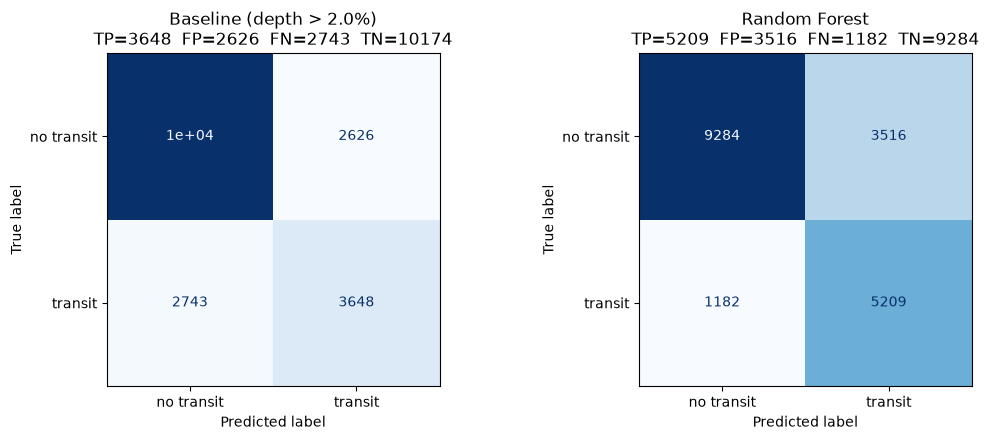

,baseline,model
precision,0.581,0.597
recall,0.571,0.815
F1,0.576,0.689
false positives,2626.000,3516.000


In [9]:
# Step 9: confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, name in [(axes[0], baseline_prediction, f"Baseline (depth > {threshold}%)"),
                       (axes[1], model_prediction, "Random Forest")]:
    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(cm, display_labels=["no transit", "transit"]).plot(ax=ax, colorbar=False, cmap="Blues")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nTP={tp}  FP={fp}  FN={fn}  TN={tn}")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "baseline": [precision_score(y, baseline_prediction), recall_score(y, baseline_prediction),
                 f1_score(y, baseline_prediction), int(((baseline_prediction == 1) & (y == 0)).sum())],
    "model": [precision_score(y, model_prediction), recall_score(y, model_prediction),
              f1_score(y, model_prediction), int(((model_prediction == 1) & (y == 0)).sum())],
}, index=["precision", "recall", "F1", "false positives"]).round(3)
comparison

### Step 9c — The fair comparison: same recall, fewer false positives

The table above is **not** a fair comparison. At its default setting the model catches far more real transits
(higher recall) but also flags more candidates, so counting raw false positives is misleading.

The honest way to compare two detectors is to set them to the **same recall** — make them catch the same
fraction of real transits — and then ask which one produces fewer false alarms.

In [10]:
# Step 9c: put the model at the same recall as the baseline, then count false positives
baseline_recall = recall_score(y, baseline_prediction)
precisions, recalls, thresholds = precision_recall_curve(y, model_score)

# pick the model threshold whose recall is closest to the baseline recall
i = int(np.argmin(np.abs(recalls[:-1] - baseline_recall)))
matched_prediction = (model_score >= thresholds[i]).astype(int)

fair = pd.DataFrame({
    "baseline": [recall_score(y, baseline_prediction), precision_score(y, baseline_prediction),
                 int(((baseline_prediction == 1) & (y == 0)).sum())],
    "model at same recall": [recall_score(y, matched_prediction), precision_score(y, matched_prediction),
                             int(((matched_prediction == 1) & (y == 0)).sum())],
}, index=["recall (same for both)", "precision", "false positives"]).round(3)
print(fair)

removed = int(((baseline_prediction == 1) & (y == 0)).sum()) - int(((matched_prediction == 1) & (y == 0)).sum())
print(f"\nAt the same recall, the model removes {removed} false positives "
      f"({100 * removed / max(1, ((baseline_prediction == 1) & (y == 0)).sum()):.0f}% fewer).")
print(f"Average precision (area under the precision-recall curve): {average_precision_score(y, model_score):.3f}")

                        baseline  model at same recall
recall (same for both)     0.571                 0.571
precision                  0.581                 0.694
false positives         2626.000              1608.000

At the same recall, the model removes 1018 false positives (39% fewer).
Average precision (area under the precision-recall curve): 0.770


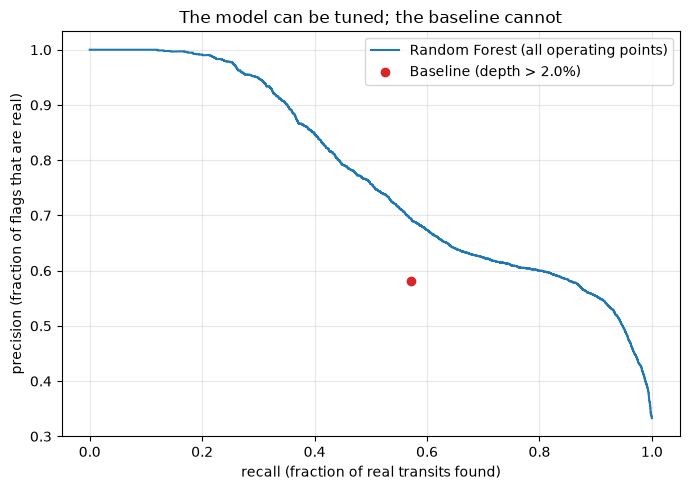

In [11]:
# Step 9c (chart): the whole precision-recall curve, with the baseline as a single point
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label="Random Forest (all operating points)")
plt.scatter([recall_score(y, baseline_prediction)], [precision_score(y, baseline_prediction)],
            color="tab:red", zorder=5, label=f"Baseline (depth > {threshold}%)")
plt.xlabel("recall (fraction of real transits found)")
plt.ylabel("precision (fraction of flags that are real)")
plt.title("The model can be tuned; the baseline cannot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 9d — Which idea is actually doing the work?

`altitude_change` came out as a strong feature. That is worth checking rather than celebrating: our artificial transits
are injected at **random times**, while real dips caused by the atmosphere happen mostly at particular times of the night
(when the star is low, or near dawn). So the model could be learning *when in the night we are* instead of
*what a transit looks like*.

To find out, we retrain with restricted feature sets and compare.

In [12]:
# Step 9d: ablation — how much does each group of features contribute?
SHAPE_ONLY = ["depth_%", "snr", "width_min", "n_in"]                     # only the dip itself
SHAPE_PLUS_OTHERS = SHAPE_ONLY + ["others_dip_%"]                        # + did other stars dip too?
CONDITIONS_ONLY = ["altitude_mean", "altitude_change", "weather_mean",   # only observing conditions
                   "sky_change_%", "drift_in_window", "night_scatter_%"]

def evaluate(feature_names):
    Xs = data[feature_names].values
    score = np.zeros(len(data))
    for train_idx, test_idx in GroupKFold(n_splits=5).split(Xs, y, groups):
        m = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
        m.fit(Xs[train_idx], y[train_idx])
        score[test_idx] = m.predict_proba(Xs[test_idx])[:, 1]
    p, r, th = precision_recall_curve(y, score)
    j = int(np.argmin(np.abs(r[:-1] - baseline_recall)))
    pred = (score >= th[j]).astype(int)
    return {"average precision": average_precision_score(y, score),
            "precision at baseline recall": precision_score(y, pred),
            "false positives": int(((pred == 1) & (y == 0)).sum())}

ablation = pd.DataFrame({
    "dip shape only": evaluate(SHAPE_ONLY),
    "shape + others_dip": evaluate(SHAPE_PLUS_OTHERS),
    "observing conditions only": evaluate(CONDITIONS_ONLY),
    "everything": evaluate(FEATURES),
}).T.round(3)
ablation

,average precision,precision at baseline recall,false positives
dip shape only,0.655,0.683,1697.0
shape + others_dip,0.737,0.721,1413.0
observing conditions only,0.635,0.604,2394.0
everything,0.770,0.694,1608.0


**How to read this table.** If "dip shape only" is already close to "everything", then the model is genuinely
recognising transit-shaped dips. If "observing conditions only" scores highly on its own, then part of the performance
comes from *when* the dip happened, not *what it looks like* — a weakness we must state openly, and a direct consequence
of injecting transits at random times. Either way, we report what we measured.

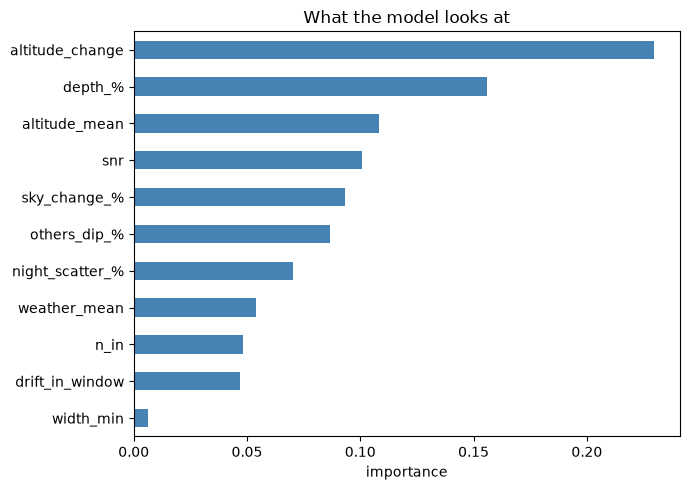

altitude_change    0.230
depth_%            0.156
altitude_mean      0.108
snr                0.101
sky_change_%       0.093
others_dip_%       0.087
night_scatter_%    0.070
weather_mean       0.054
n_in               0.048
drift_in_window    0.047
width_min          0.006
dtype: float64

In [13]:
# Step 9b: which features did the model actually use?
final_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1).fit(X, y)
importance = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values()
importance.plot(kind="barh", figsize=(7, 5), color="steelblue")
plt.title("What the model looks at")
plt.xlabel("importance")
plt.tight_layout()
plt.show()
importance.sort_values(ascending=False).round(3)

## Step 10 — Where does the solution fail?

The jury will ask "when does it fail?". The honest answer: **shallow transits on bad nights**.
Here we measure exactly where the limit is.

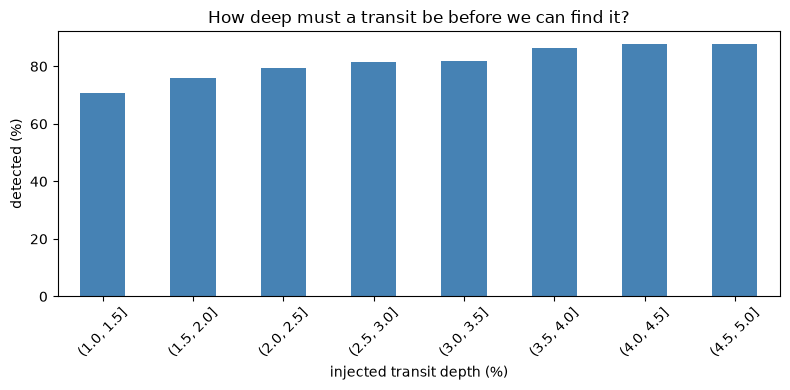

depth_bin
(1.0, 1.5]    70.7
(1.5, 2.0]    75.9
(2.0, 2.5]    79.4
(2.5, 3.0]    81.6
(3.0, 3.5]    81.8
(3.5, 4.0]    86.5
(4.0, 4.5]    87.8
(4.5, 5.0]    87.7
Name: found, dtype: float64

In [14]:
# Step 10: detection rate as a function of how deep the transit is
injected = data[data.case == "injected"].copy()
injected["found"] = model_prediction[data.case == "injected"] == 1
bins = np.arange(1, 5.5, 0.5)
injected["depth_bin"] = pd.cut(injected["injected_depth_%"], bins)
rate = injected.groupby("depth_bin", observed=True).found.mean() * 100

ax = rate.plot(kind="bar", figsize=(8, 4), color="steelblue")
ax.set_ylabel("detected (%)")
ax.set_xlabel("injected transit depth (%)")
ax.set_title("How deep must a transit be before we can find it?")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
rate.round(1)

In [15]:
# Step 10b: the same, but split by how good the night was
injected["night_quality"] = np.where(injected["night_scatter_%"] < 2, "good night (<2% scatter)", "bad night (>2%)")
summary = injected.groupby(["night_quality", "depth_bin"], observed=True).found.mean().unstack() * 100
summary.round(0)

depth_bin,"(1.0, 1.5]","(1.5, 2.0]","(2.0, 2.5]","(2.5, 3.0]","(3.0, 3.5]","(3.5, 4.0]","(4.0, 4.5]","(4.5, 5.0]"
night_quality,,,,,,,,
bad night (>2%),74.0,74.0,75.0,77.0,77.0,84.0,87.0,86.0
good night (<2% scatter),64.0,79.0,86.0,89.0,91.0,93.0,92.0,98.0


## Step 11 — Bonus: run the detector on the real transit windows

Our model was trained on injected transits. Here we point it at the **real** predicted transit windows
of the central star and see whether anything shows up. This is a fair test on data the model never saw as positives.

In [16]:
# Step 11: point the trained model at the REAL predicted transit windows.
# The planet host is the star the telescope pointed at, so it is the star closest to the image centre.
lc["distance_from_centre"] = np.hypot(lc.star_x - 325, lc.star_y - 250)
central = lc.loc[lc.groupby(["target", "night"]).distance_from_centre.idxmin(), ["target", "night", "star_id"]]

real_rows = []
for _, row in central.iterrows():
    g = lc[(lc.target == row.target) & (lc.night == row.night) & (lc.star_id == row.star_id)].sort_values("mjd")
    if len(g) < 30:
        continue
    t = (g.mjd.values - g.mjd.values.min()) * 24
    others = (lc[(lc.target == row.target) & (lc.night == row.night) & (lc.star_id != row.star_id)]
              .groupby("mjd").rel_flux.mean().reindex(g.mjd.values).values)
    candidates = features_for_curve(g, g.rel_flux.values, others, label_window=None).dropna(subset=FEATURES)
    if len(candidates) == 0:
        continue

    # train on every OTHER night, so this night is completely unseen
    unseen = groups != f"{row.target} {row.night}"
    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
    model.fit(X[unseen], y[unseen])
    candidates["score"] = model.predict_proba(candidates[FEATURES].values)[:, 1]

    real = g.in_transit_window.values
    inside = np.array([real[np.argmin(np.abs(t - c))] for c in candidates.centre_hours])
    real_rows.append({
        "target": row.target, "night": row.night,
        "score_in_transit": candidates.score[inside].max() if inside.any() else np.nan,
        "score_outside": candidates.score[~inside].max() if (~inside).any() else np.nan,
        "deepest_dip_in_transit_%": candidates["depth_%"][inside].max() if inside.any() else np.nan,
    })

real_check = pd.DataFrame(real_rows)
real_check["higher_inside"] = real_check.score_in_transit > real_check.score_outside
print(f"nights where the strongest candidate sits inside the real transit window: "
      f"{real_check.higher_inside.sum()} of {len(real_check)}")
real_check.sort_values("score_in_transit", ascending=False).round(3)

nights where the strongest candidate sits inside the real transit window: 13 of 16


,target,night,score_in_transit,score_outside,deepest_dip_in_transit_%,higher_inside
13,TRES-5,2026-09-01,0.956,0.877,1.252,True
9,TRES-5,2026-08-17,0.936,0.882,0.835,True
14,TRES-5,2026-09-04,0.836,0.865,2.190,False
1,CoRoT-2,2026-08-16,0.833,0.525,0.997,True
0,CoRoT-2,2026-08-09,0.823,0.510,1.495,True
2,HATP-10,2026-09-05,0.807,0.287,1.941,True
15,WASP-2,2026-08-24,0.751,0.937,7.262,False
4,Qatar-1,2026-08-21,0.751,0.607,0.980,True
10,TRES-5,2026-08-20,0.735,0.698,17.763,True
8,TRES-3,2026-08-31,0.670,0.509,6.134,True


**How to read this honestly.** If the score inside the real window were consistently higher than outside, that
would be evidence we are picking up the real transits. If it is roughly half the nights, that is what pure chance
looks like, and the correct conclusion is that our precision (~1% on the best nights) is not enough for transits of
1.6–2.75% in this data. We report the number either way — a candidate is not a discovery.

## Summary for the README

- **Problem:** tell real transit-like dips apart from dips caused by clouds, airmass and noise.
- **Why not real transits as labels:** all 22 nights were scheduled on a transit, so there are no natural negatives, and 8 planets is far too few.
- **Method:** injection and recovery on real light curves — thousands of certain labels.
- **Validation:** split by night with `GroupKFold`, so no night is both trained and tested.
- **Baseline:** a depth threshold. **Model:** Random Forest, compared **at the same recall** (Step 9c), because comparing raw false-positive counts at different recalls is meaningless.
- **Honesty note:** at its default setting the model finds many more real transits but also flags more candidates. The fair comparison is Step 9c; the ablation in Step 9d shows how much comes from the dip shape itself versus the observing conditions.
- **Limits:** we detect deep transits on good nights; shallow transits on cloudy nights are missed. The numbers are in Step 10.

## Try it yourself

1. Change `threshold` in Step 7 from 2.0 to 1.0 and to 3.0. What happens to false positives and to recall? Why is there no single perfect threshold?
2. Remove `others_dip_%` from `FEATURES` and retrain. How much worse does the model get? This proves which idea is doing the work.
3. Change the injected depth range in Step 5 to 0.5–2%. Does the model still work? What does that tell us about our limits?